<a href="https://colab.research.google.com/github/almaalifia/Analisis-Deret-Waktu/blob/main/Hands_On_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Alma Alifia Halimatunnisa

**NIM:** M0501251004

**Tugas 2 Praktikum Analisis Deret Waktu**

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [513]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [514]:
# NIM M0501251004
EMPAT_DIGIT_TERAKHIR_NIM=1004
DUA_DIGIT_TERAKHIR_NIM=4

# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(EMPAT_DIGIT_TERAKHIR_NIM)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 + DUA_DIGIT_TERAKHIR_NIM
beta0 = 10 + DUA_DIGIT_TERAKHIR_NIM
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


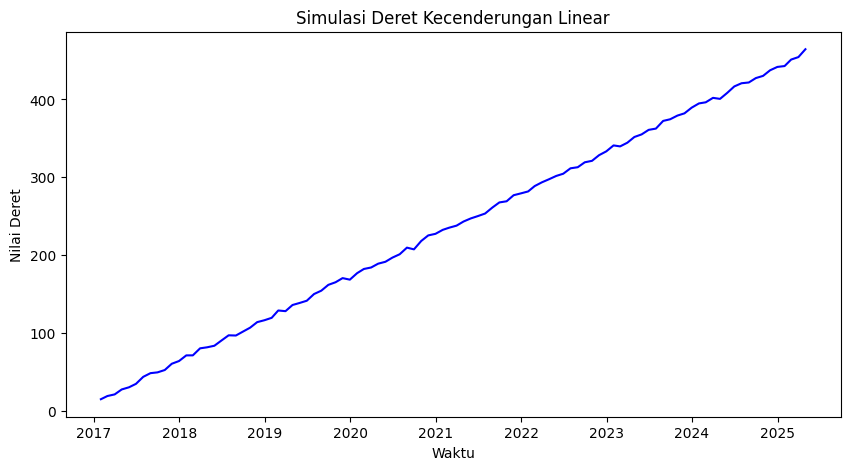

In [515]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Cek apakah ada korelasi antar pengamatan?**

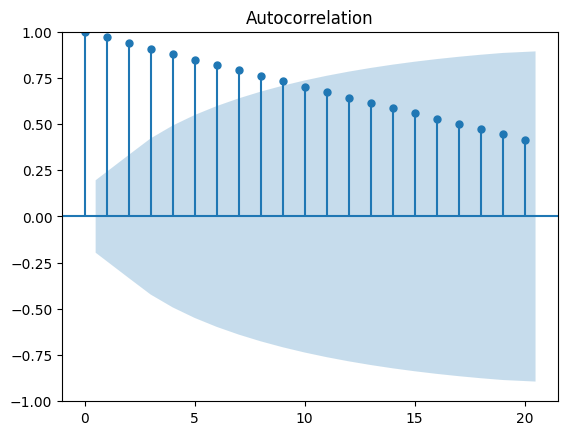

In [516]:
# Cek korelasi antar pengamatan dengan ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["Value"], lags=20)
plt.show()

In [517]:
# Nilai lag

for lag in range(1, 21):
    korelasi = df["Value"].autocorr(lag=lag)
    print(f"Lag {lag}: {korelasi:.4f}")

Lag 1: 0.9998
Lag 2: 0.9997
Lag 3: 0.9997
Lag 4: 0.9997
Lag 5: 0.9997
Lag 6: 0.9997
Lag 7: 0.9997
Lag 8: 0.9996
Lag 9: 0.9997
Lag 10: 0.9997
Lag 11: 0.9997
Lag 12: 0.9996
Lag 13: 0.9997
Lag 14: 0.9997
Lag 15: 0.9997
Lag 16: 0.9997
Lag 17: 0.9996
Lag 18: 0.9997
Lag 19: 0.9996
Lag 20: 0.9996


**Jawab:**

Nilai lag 1 hingga lag 20 menunjukkan terdapat autokorelasi yang tinggi dan positif. Pada lag 1, nilai autokorelasi mendekati 1 yang menunjukkan adanya hubungan yang sangat kuat antara pengamatan pada suatu periode (Yt) dengan pengamatan pada satu periode sebelumnya (Yt-1). Seiring bertambahnya nilai lag, nilai autokorelasi secara bertahap mengalami penurunan, tetapi masih bernilai positif dan tetap tinggi hingga lag 20.

Pola plot Autocorrelation Function (ACF) yang menurun secara perlahan menunjukkan bahwa pengamatan pada suatu periode tidak bersifat independen terhadap pengamatan pada periode sebelumnya. Korelasi positif yang kuat ini menunjukkan adanya ketergantungan temporal (autokorelasi) dalam deret waktu. Tingginya autokorelasi pada data ini berkaitan dengan adanya kecenderungan linear positif, di mana nilai deret relatif meningkat secara konsisten dari waktu ke waktu.

In [518]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 0.9999


In [519]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.917e+05
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          2.60e-178
Time:                        14:56:44   Log-Likelihood:                -213.80
No. Observations:                 100   AIC:                             431.6
Df Residuals:                      98   BIC:                             436.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           14.2344      0.412     34.585   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

**Jawab:**

Hasil pengepasan model regresi menunjukkan bahwa parameter yang diestimasi menggunakan metode Ordinary Least Squares (OLS) sangat mendekati nilai parameter asli yang digunakan dalam pembangkitan data. Parameter asli yang digunakan adalah (beta0=14) dan (beta1=4.5), sedangkan hasil estimasi OLS masing-masing sebesar 14.2344 dan 4.4954.

Dengan demikian, selisih antara parameter asli dan hasil estimasi relatif kecil, yaitu sebesar 0.2344 untuk intercept dan 0.0046 untuk koefisien trend. Perbedaan tersebut disebabkan oleh adanya noise acak yang ditambahkan pada data simulasi. Secara keseluruhan, hasil pengepasan model regresi mampu mengestimasi parameter asli dengan sangat baik. Hal ini juga didukung oleh nilai (R^2) sebesar 1 yang menunjukkan bahwa model regresi mampu menjelaskan hampir seluruh variasi pada data.

**Apakah model regresi yang dipaskan sudah bagus?**

**Jawab:**

Model regresi yang dipaskan dapat dikatakan sudah sangat baik. Hal ini ditunjukkan oleh nilai R^2 sebesar 1 yang menunjukkan bahwa model sangat mampu menjelaskan hampir seluruh variasi pada data. Selain itu, koefisien trend sebesar 4.4954 memiliki p-value sebesar 0 sehingga koefisien trend signifikan secara statistik. Model secara keseluruhan juga signifikan berdasarkan F-statistic sbeesar 2.6 x 10^(-178) yang lebih kecil dari 0.05.

Dengan demikian, model regresi linear yang dipaskan sudah sangat baik dalam menggambarkan pola trend linear.

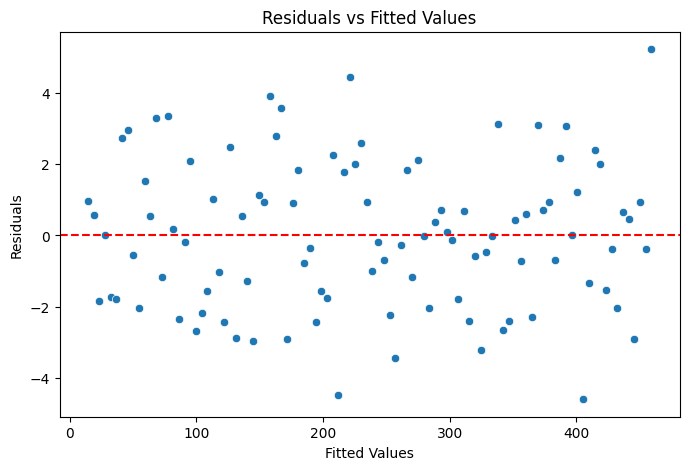

In [520]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

**Jawab:**

Berdasarkan plot Residuals vs Fitted Values, terlihat bahwa residual tersebar di sekitar garis nol dengan pola yang relatif acak. Residual berada di atas maupun di bawah garis nol dan tidak menunjukkan pola tertentu.

Residual yang tersebar secara acak di sekitar garis nol dan tidak menunjukkan pola tertentu menunjukkan bahwa asumsi linearitas dan homoskedastisitas secara visual dapat dikatakan terpenuhi. Artinya model regresi linear yang digunakan sudah cukup baik dalam menangkap pola hubungan antara waktu dan nilai deret, sehingga sisaan yang dihasilkan tidak menunjukkan pola tertentu yang masih dapat dijelaskan oleh model.

Misal:

- Fitted value = 200

- Residual = +3

Artinya pada pengamatan tersebutm model memprediksi nilai sekitar 200, tetapi nilai aktualnya sekitar 203.

Residual positif dan negatif harus tersebar secara acak karena model yang baik tidak terus-menerus memprediksi di bawah garis 0 (underestimate) dan di atas garis 0 (overestimate).


In [521]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.7478


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

**Jawab**

Breusch-Pagan Test menguji apakah terdapat heteroskedastisitas pada residual.

- H0: tidak ada heteroskedastisitas

- H1: terdapat heteroskedastisitas

Hasil menunjukkan P-value Breusch-Pagan Test: 0.7478 dengan taraf signifikansi 0.05. Maka gagal menolak H0.

Dengan demikian, tidak terdapat cukup bukti untuk menyatakan adanya heteroskedastisitas pada residual. Artinya, residual dapat dianggap memiliki varians yang konstan (homoskedastis). Dengan demikian, asumsi homoskedastisitas pada model regresi terpenuhi.

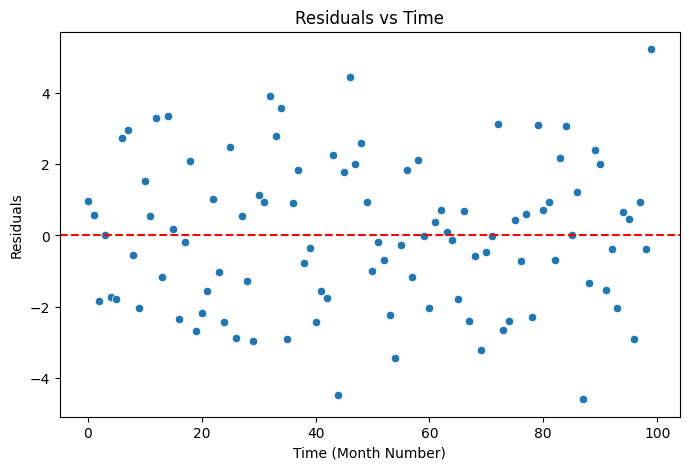

In [522]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

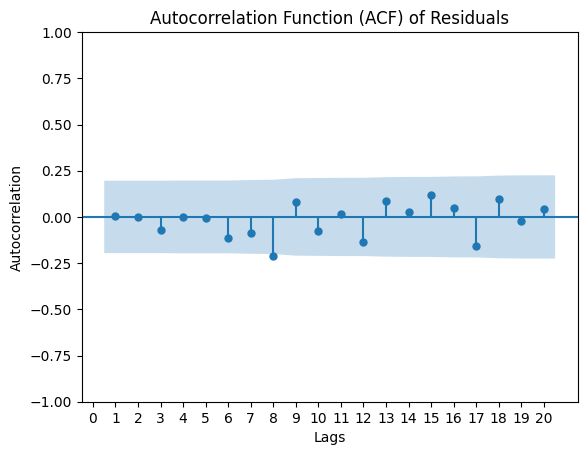

In [523]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

**Jawab:**

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi pada lag 1 hinngga lag20 berada di dalam batas interval kepercayaan. Tidak terlihat pola autokorelasi yang kuat maupun pola tertentu yang sistematis pada residual. Hal ini menunjukkan bahwa residual tidak memiliki autokorelasi yang signifikan, sehingga residual dapat dianggat independen antar waktu.

Dengan demikian, model regresi linear telah mampu menangkap pola tren pada data dengan baik.

Berbeda dengan ACF data awal yang menunjukkan autokorelasi sangat tinggi akibat adanya tren linear, ACF residual menunjukkan autokorelasi tersebut sudah tidak terlihat setelah tren dimasukkan ke dalam model regresi.

In [524]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.004841   0.944530
2    0.005642   0.997183
3    0.530325   0.912180
4    0.530803   0.970434
5    0.538256   0.990655
6    2.016437   0.918181
7    2.865189   0.897187
8    7.923658   0.440963
9    8.619619   0.473101
10   9.232599   0.510181
11   9.266337   0.597323
12  11.335042   0.500445
13  12.245892   0.507591
14  12.341645   0.578887
15  13.997672   0.525706
16  14.280439   0.577830
17  17.316564   0.433126
18  18.435980   0.427298
19  18.488701   0.490048


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

**Jawab:**

Uji Ljung-Box pada residual untuk memeriksa apakah residual masih memiliki autokorelasi, tetapi memiliki pendekatan yang berbeda dari melihat ACF.

Hipotesis:

- H0: tidak terdapat autokorelasi pada residual hingga lag tertentu

- H1: terdapat autokorelasi pada residual hingga lag tertentu.

dengan alpha 0.05

Hasil menunjukkan p-value pada lag1 hingga lag20 seluruhnya lebih besar dari taraf signifikansi (0.05). P-value terkecil pada lag 9 yaitu sebesar 0.062599. Oleh karena itu, H0 gagal ditolak. Dengan demikian tidak terdapat bukti yang cukup untuk menyatakan adanya autokorelasi pada independen antar waktu.

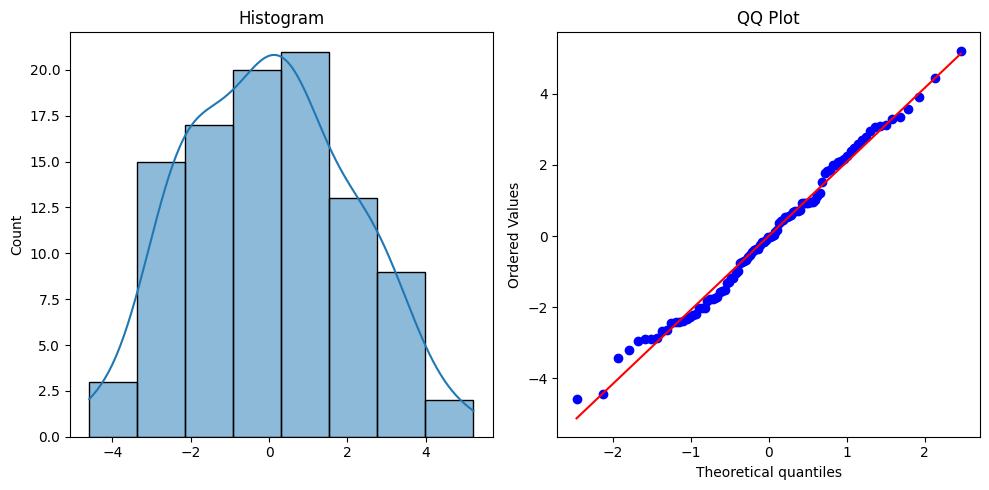

In [525]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**

**Jawab:**

Berdasarkan histogram residual, terlihat bahwa residual memiliki distribusi yang relatif simetris dan berbentuk menyerupai lonceng, dengan sebagian besar residual terkonsentrasi di sekitar nilai 0. Hal ini menunjukkan bahwa residual cenderung mengikuti pola distribusi normal.

Pada Q-Q Plot, sebagian besar titik pengamatan berada dekat dengan garis diagonal, terutama pada bagian tengah distribusi. Meskipun terdapat sedikit penyimpangan pada bagian ekor, pola titik secara keseluruhan masih mengikuti garis diagonal dengan cukup baik. Hal ini menunjukkan bahwa distribusi residual secara visual mendekati distribusi normal.

In [526]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9884032568686306, p-value = 0.5383997124337613


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?**

**Jawab:**

Hipotesis Shapiro-Wilk Test:

- H0: residual berdistribusi normal

- H1: residual tidak berdistribusi normal

Karena 0.5587 > 0.05 maka gagal menolak H0. Artinya, tidak cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal.

Dari histogram dan Q-Q plot menunjukkan bahwa residual cenderung mengikuti distribusi normal. Dengan demikian, tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal, sehingga asumsi normalitas residual dapat dianggap terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [527]:
# NIM M0501251004
EMPAT_DIGIT_TERAKHIR_NIM=1004
DUA_DIGIT_TERAKHIR_NIM=4

# Menentukan parameter simulasi
np.random.seed(EMPAT_DIGIT_TERAKHIR_NIM)
n_periods = 120
beta_0, beta_1, beta_2= 50 + DUA_DIGIT_TERAKHIR_NIM, 0.5 + DUA_DIGIT_TERAKHIR_NIM, 0.02 + DUA_DIGIT_TERAKHIR_NIM
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

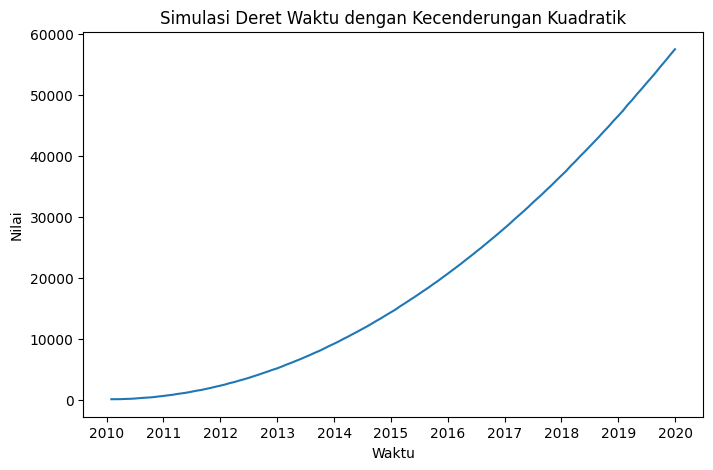

In [528]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?**

**Jawab:**

Berdasarkan plot, deret waktu menunjukkan kecenderungan meningkat dengan pola yang tidak linear. Nilai deret terus mengalami peningkatan dari waktu ke waktu dengan laju peningkatan yang semakin besar pada periode-periode berikutnya.

Berdasarkan bentuk kurva yang semakin curam, plot memiliki pola berbentuk menyerupai kurva kuadratik. Dengan demikian, deret memiliki kecenderungan kuadratik positif, yaitu pertumbuhan nilai semakin cepat seiring bertambahnya waktu.

**Perbedaan utama** kecenderungan linear dengan kecenderungan kuadratik terletak pada laju perubahan deret. Pada kecenderungan linear, nilai deret meningkat dengan laju yang relatif konstan sehingga membentuk garis lurus. Sedangkan kecenderungan kuadratik, laju perubahan nilai deret tidak konstan dan semakin meningkat seiring waktu sehingga membentuk kurva yang semakin curam.

In [529]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.604e+08
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:56:46   Log-Likelihood:                -451.67
No. Observations:                 120   AIC:                             909.3
Df Residuals:                     117   BIC:                             917.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.9251      2.846     20.002      0.0

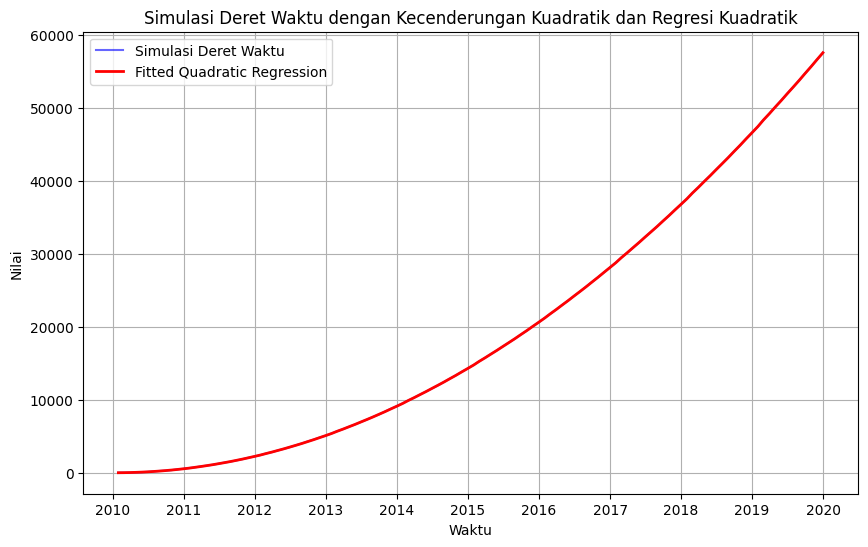

In [530]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

**Jawab:**
Asumsi-asumsi yang perlu dicek:

- Linearitas dalam parameter

- Homoskedastisitas

- Tidak ada autokorelasi residual

- Normalitas residual


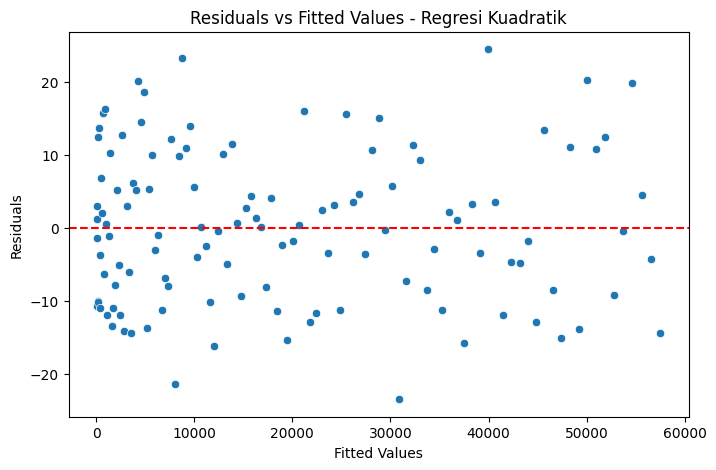

In [531]:
# cek asumsi model regresi kuadratik
# 1. residual vs fitted values (asumsi linearitas dalam parameter)
plt.figure(figsize=(8,5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values - Regresi Kuadratik")
plt.show()

Berdasarkan hasil residuals vs fitted values, titik residual tersebar acak di sekitar 0 dan tidak membentuk pola tertentu. Dengan demikian, model memenuhi asumsi linearitas dalam parameter.

In [532]:
# 2. Uji Breusch-Pagan (asumsi homoskedastisitas)
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

Breusch-Pagan Test
LM Statistic: 0.8440248474470868
LM p-value: 0.6557258927856239
F Statistic: 0.4143766480232316
F p-value: 0.661717896604512


Berdasarkan hasil Breusch-Pagan Test, diperoleh LM p-value sebesar 0.6557 dan F p-value sebesar 0.6617. Kedua p-value lebih besar dari taraf signifikansi 0.05, sehingga (H0) gagal ditolak. Dengan demikian, tidak terdapat cukup bukti untuk menyatakan adanya heteroskedastisitas pada residual. Artinya, varians residual dapat dianggap konstan atau memenuhi asumsi homoskedastisitas.

<Figure size 800x500 with 0 Axes>

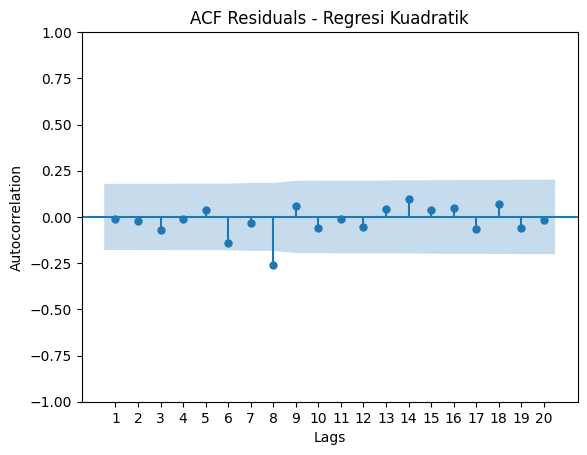

In [533]:
#3. Tidak ada autokorelasi residual (asumsi 3)

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,5))
plot_acf(model_quad.resid, lags=20, zero=False)
plt.xticks(range(1,21))
plt.title("ACF Residuals - Regresi Kuadratik")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()

Berdasarkan plot ACF residual pada lag 1 hingga 20, sebagian besar nilai autokorelasi berada di dalam batas interval kepercayaan. Meskipun terdapat satu spike yang melewati batas interval kepercayaan pada lag 8, secara keseluruhan tidak terlihat pola autokorelasi yang kuat dan sistematis. Hal ini menunjukkan bahwa residual secara umum tidak memiliki autokorelasi yang signifikan.

In [534]:
# Ljung Box (asumsi 3 tidak ada autokorelasi)
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(model_quad.resid, lags=20, return_df=True)

print(ljung_box)

      lb_stat  lb_pvalue
1    0.016993   0.896283
2    0.092526   0.954791
3    0.760107   0.858983
4    0.782762   0.940744
5    0.982355   0.963976
6    3.531244   0.739808
7    3.681667   0.815626
8   12.702817   0.122492
9   13.202977   0.153635
10  13.700612   0.187091
11  13.717280   0.249034
12  14.100963   0.294307
13  14.354624   0.349352
14  15.686964   0.332862
15  15.890572   0.389361
16  16.246870   0.435868
17  16.891425   0.461745
18  17.540268   0.486302
19  18.021719   0.520988
20  18.068608   0.582889


Berdasarkan hasil uji Ljung-Box, seluruh p-value pada lag 1 hingga lag 20 lebih besar dari taraf signifikansi 0.05. Pada lag 8, misalnya, diperoleh p-value sebesar 0,1225 yang juga lebih besar dari 0,05. Oleh karena itu, (H0) gagal ditolak. Dengan demikian, tidak terdapat cukup bukti adanya autokorelasi pada residual hingga lag 20.

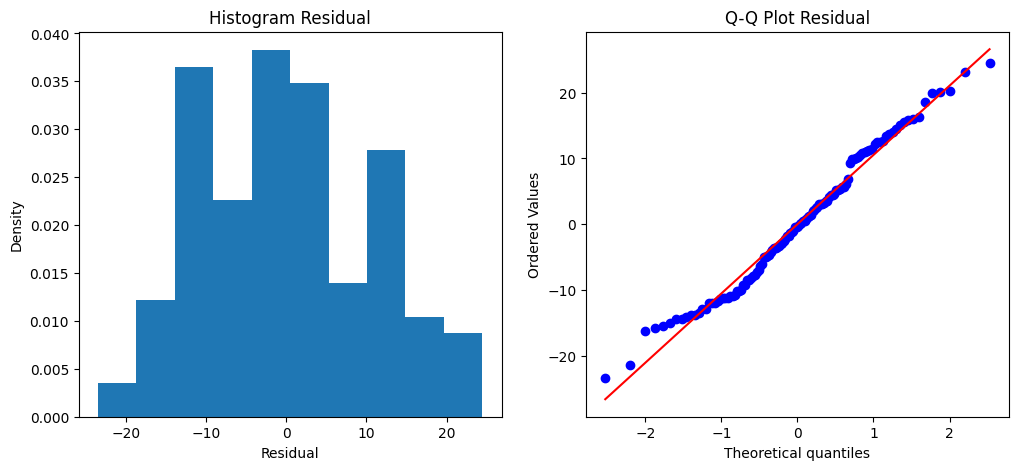

In [535]:
# 4. Normalitas residual
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
axes[0].hist(model_quad.resid, bins=10, density=True)
axes[0].set_title("Histogram Residual")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Density")

# Q-Q Plot
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot Residual")

plt.show()

Berdasarkan histogram dan Q-Q Plot, residual secara visual cenderung mengikuti distribusi normal. Histogram menunjukkan residual yang terpusat di sekitar nilai 0, sedangkan pada Q-Q Plot sebagian besar titik berada di sekitar garis diagonal. Meskipun terdapat beberapa penyimpangan pada bagian ekor, penyimpangan tersebut tidak terlalu besar. Dengan demikian, secara visual asumsi normalitas residual dapat dianggap terpenuhi.

In [536]:
# Shapiro Wilk
from scipy.stats import shapiro

stat, p_value = shapiro(model_quad.resid)

print("Shapiro-Wilk Test")
print("Statistic =", stat)
print("p-value =", p_value)

Shapiro-Wilk Test
Statistic = 0.9807873354925934
p-value = 0.08428768877354484


Berdasarkan hasil uji Shapiro-Wilk, diperoleh statistik uji sebesar 0,9808 dengan p-value sebesar 0,0843. Karena p-value lebih besar dari taraf signifikansi 0,05, maka \(H_0\) gagal ditolak. Dengan demikian, tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal, sehingga residual dapat dianggap berdistribusi normal.

Berdasarkan seluruh hasil pengujian, semua asumsi model regresi kuadratik terpenuhi, meliputi linearitas, homoskedastisitas, tidak adanya autokorelasi, dan normalitas residual. Dengan demikian, model regresi kuadratik yang dipaskan terhadap deret sudah memenuhi asumsi-asumsi yang diperlukan.

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

**Jawab:**

Berdasarkan plot, model regresi kuadratik yang dipaskan sudah sesuai dengan pola deret waktu. Garis hasil pengepasan (fitted quadratic regression) terlihat mengikuti pola deret simulasi dengan sangat baik, termasuk kecenderungan nilai yang semakin meningkat dan semakin curam seiring bertambahnya waktu. Hal ini menunjukkan bahwa bentuk kuadratik mampu menangkap kecenderungan non-linear pada deret dengan baik.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [537]:
# NIM M0501251004
EMPAT_DIGIT_TERAKHIR_NIM=1004
DUA_DIGIT_TERAKHIR_NIM=4

# Menentukan parameter simulasi
np.random.seed(EMPAT_DIGIT_TERAKHIR_NIM)
n_periods = 120
beta0, beta1, beta2=50+DUA_DIGIT_TERAKHIR_NIM,-25+DUA_DIGIT_TERAKHIR_NIM, -2+DUA_DIGIT_TERAKHIR_NIM
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


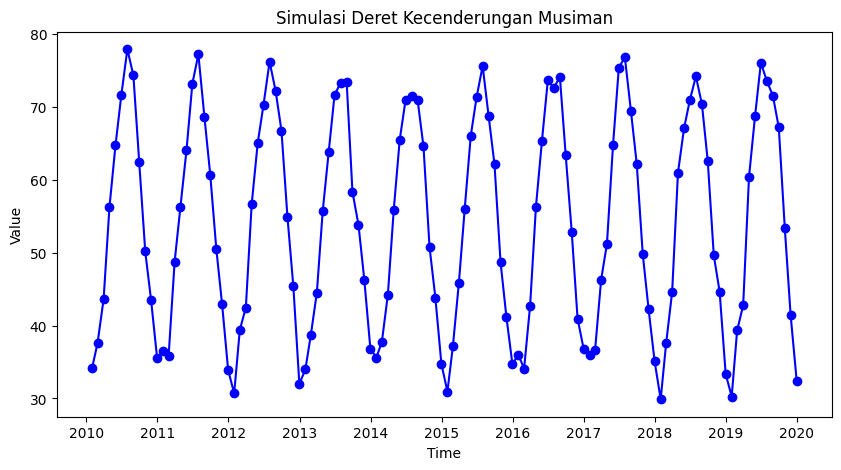

In [538]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**

**Jawab:**

Berdasarkan plot, deret menunjukkan pola musiman yang berulang secara teratur setiap 12 periode atau 12 bulan. Hal ini terlihat dari pola naik dan turun yang relatif sama dan berulang dari tahun ke tahun. Nilai deret cenderung mencapai puncak dan lembah pada periode yang hampir sama setiap tahunnya.

Deret tidak menunjukkan kecenderungan meningkat atau menurun dalam jangka panjang, sehingga tidak terdapat tren yang dominan. Fluktuasi yang terlihat terutama disebabkan oleh komponen musiman dengan periode 12 bulan, sedangkan variasi kecil di sekitar pola musiman disebabkan oleh noise acak. Dengan demikian, deret dapat dikatakan memiliki pola musiman tahunan yang cukup kuat, dengan satu siklus yang berulang setiap 12 bulan.

In [539]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [540]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [541]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [542]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     529.4
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           1.55e-88
Time:                        14:56:47   Log-Likelihood:                -253.54
No. Observations:                 120   AIC:                             531.1
Df Residuals:                     108   BIC:                             564.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       33.3942      0.667     50.056      0.0

**Bagaimana interpretasi dari hasil tersebut?**

**Jawab:**

Berdasarkan hasil regresi dengan dummy variabel musiman, diperoleh nilai (R^2) sebesar 0,982 yang menunjukkan bahwa model mampu menjelaskan sekitar 98.2% variasi nilai deret melalui pola musiman bulanan. Nilai koefisien menunjukkan pola nilai deret yang berbeda pada setiap bulan. Nilai deret meningkat dari Januari hingga mencapai nilai tertinggi pada Juli sebesar 74.9008, kemudian menurun hingga Desember sebesar 34.5412.

Seluruh koefisien dummy bulan memiliki p-value sebesar 0,000 (< 0.05), sehingga efek masing-masing bulan signifikan secara statistik. Selain itu, p-value uji F sebesar 1.55 x 10^(-88) (< 0.05) menunjukkan bahwa model secara keseluruhan signifikan. Dengan demikian, model regresi dummy musiman mampu menangkap pola musiman 12 bulanan pada deret dengan sangat baik.

In [543]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

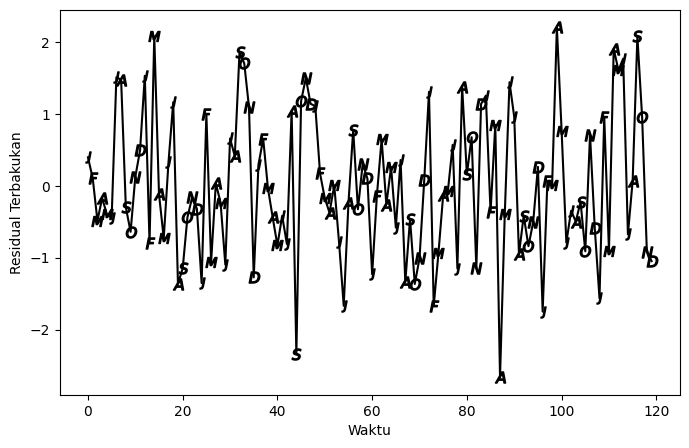

In [544]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


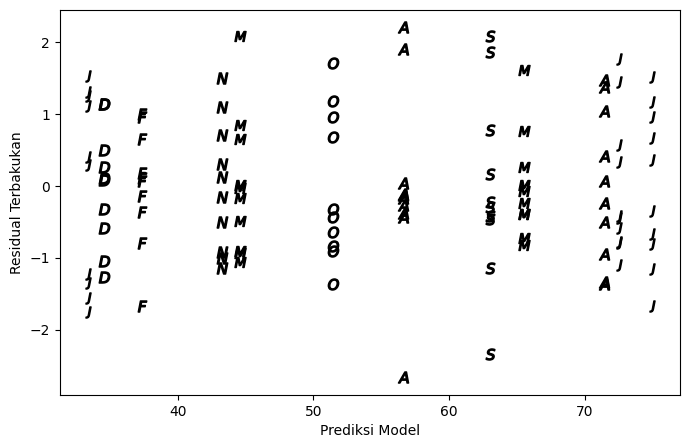

In [545]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

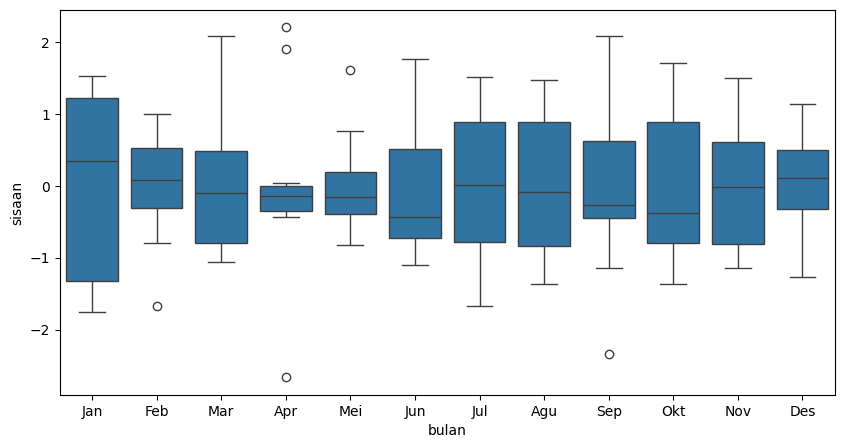

In [546]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap tiga plot di atas?**

**Jawab:**

1. Residual terhadap waktu

Berdasarkan plot residual terhadap waktu, residual berfluktuasi di sekitar nilai 0 dan tidak menunjukkan pola tertentu yang sistematis sepanjang waktu. Residual positif dan negatif muncul secara bergantian serta tidak menunjukkan kecenderungan meningkat atau menurun. Hal ini menunjukkan bahwa model telah mampu menangkap pola musiman dalam deret, sehingga tidak terdapat pola musiman yang tersisa pada residual.

2. Residual vs Prediksi Model

Berdasarkan plot residual terhadap prediksi model, residual tersebar di sekitar nilai 0 dan tidak menunjukkan pola tertentu yang sistematis. Residual positif dan negatif muncul pada berbagai nilai prediksi. Hal ini menunjukkan bahwa tidak terdapat pola yang jelas pada residual terhadap nilai prediksi, sehingga model secara umum telah mampu menangkap pola musiman pada data.

3. Boxplot Residual berdasarkan Bulan

Berdasarkan boxplot residual untuk setiap bulan, residual pada masing-masing bulan secara umum tersebar di sekitar nilai 0. Median residual pada sebagian besar bulan berada relatif dekat dengan nilai 0. Penyebaran residual antarbulan memang berbeda, tetapi tidak menunjukkan pola yang sistematis. Terdapat beberapa pencilan pada beberapa bulan, seperti April, Mei, dan September, tetapi jumlahnya relatif sedikit.

Secara keseluruhan, ketiga plot menunjukkan bahwa residual tidak memiliki pola sistematis berdasarkan waktu, nilai prediksi, maupun bulan. Residual cenderung tersebar secara acak di sekitar nilai 0, sehingga model regresi musiman telah mampu menangkap pola utama dalam deret dengan baik.

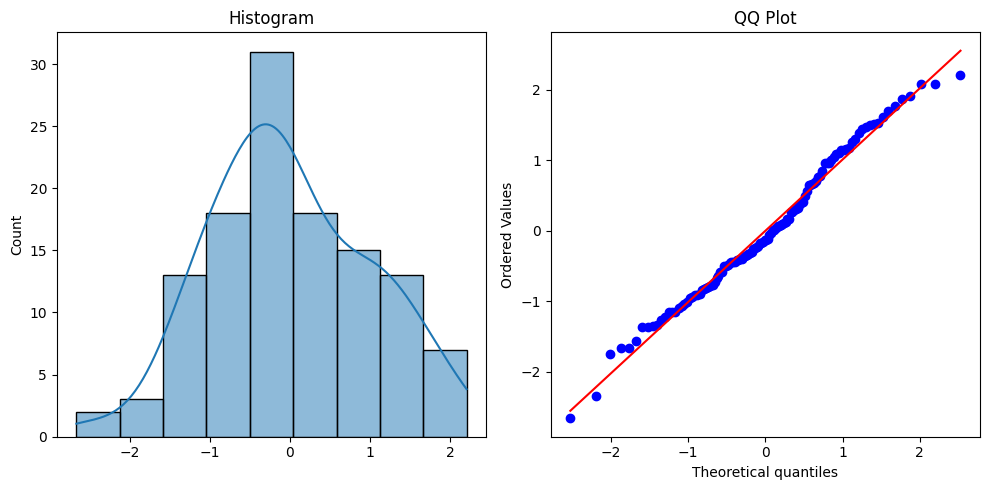

In [547]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

**Jawab:**
Berdasarkan plot residual terhadap waktu, residual terhadap prediksi model, boxplot residual berdasarkan bulan, serta histogram dan Q-Q plot, residual tidak menunjukkan pola sistematis dan cenderung tersebar di sekitar nilai 0. Selain itu, hasil pengujian sebelumnya menunjukkan bahwa asumsi homoskedastisitas, tidak adanya autokorelasi, dan normalitas residual terpenuhi. Dengan demikian, model regresi musiman yang dipaskan sudah tepat karena mampu menangkap pola musiman 12 bulanan pada deret dan tidak meninggalkan pola sistematis yang berarti pada residual.


**Hitunglah statistik uji untuk mengecek asumsi model**

**Jawab:**



In [548]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Residual model tanpa intersep
residual = musiman.resid

# Untuk Breusch-Pagan
exog_bp = sm.add_constant(musim)

bp_test = het_breuschpagan(residual, exog_bp)

print("LM Statistic :", bp_test[0])
print("LM p-value   :", bp_test[1])
print("F Statistic  :", bp_test[2])
print("F p-value    :", bp_test[3])

LM Statistic : 10.956261774590622
LM p-value   : 0.5326707463975631
F Statistic  : 0.986490117645838
F p-value    : 0.4632872335384699


In [549]:
residual = musiman.resid

# Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(residual, lags=20, return_df=True)
print(ljung)

# Shapiro-Wilk
from scipy.stats import shapiro

shapiro_test = shapiro(residual)
print("Statistic :", shapiro_test.statistic)
print("p-value   :", shapiro_test.pvalue)

      lb_stat  lb_pvalue
1    0.177714   0.673345
2    0.294694   0.862994
3    1.058404   0.787124
4    1.226821   0.873663
5    1.546376   0.907657
6    2.473353   0.871438
7    2.689287   0.912182
8    9.967639   0.267305
9   10.279148   0.328363
10  10.994711   0.357930
11  11.035729   0.440275
12  13.912293   0.306344
13  14.330150   0.351011
14  15.757604   0.328400
15  15.786159   0.396404
16  17.027973   0.383789
17  17.662665   0.410415
18  19.633780   0.353810
19  20.240288   0.380251
20  20.269361   0.441197
Statistic : 0.9863250334823657
p-value   : 0.2692606145395936


- Berdasarkan uji Breusch-Pagan, diperoleh p-value sebesar 0.5327 (LM) dan 0.4633 (F), keduanya lebih besar dari 0.05. Oleh karena itu, H₀ tidak ditolak sehingga tidak terdapat bukti adanya heteroskedastisitas. Dengan demikian, asumsi homoskedastisitas terpenuhi.

- Berdasarkan uji Ljung-Box pada lag 1 hingga 20, seluruh p-value lebih besar dari 0.05. Oleh karena itu, H₀ tidak ditolak sehingga tidak terdapat bukti adanya autokorelasi pada residual hingga lag 20. Dengan demikian, asumsi independensi residual terpenuhi.

- Berdasarkan uji Shapiro-Wilk, diperoleh statistik uji sebesar 0,9863 dengan p-value sebesar 0.2693. Karena p-value lebih besar dari 0.05, H₀ tidak ditolak sehingga residual dapat dianggap berdistribusi normal. Dengan demikian, asumsi normalitas terpenuhi.

In [550]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [551]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     529.4
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           1.55e-88
Time:                        14:56:49   Log-Likelihood:                -253.54
No. Observations:                 120   AIC:                             531.1
Df Residuals:                     108   BIC:                             564.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.3942      0.667     50.056      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**

**Apakah model dengan intersep sudah memenuhi asumsi regresi?**

**Jawab:**

Model dengan intersep memiliki R-squared sebesar 0.982, yang berarti 98.2% variasi nilai deret dapat dijelaskan oleh faktor bulan. Pada model dengan intersep, intersep menunjukkan nilai rata-rata bulan acuan, yaitu Januari, sedangkan koefisien bulan lainnya menunjukkan selisih nilai bulan tersebut terhadap Januari.

**Contoh**, nilai Januari adalah 33.3942, sedangkan koefisien Juli sebesar 41.5066 menunjukkan bahwa nilai Juli lebih tinggi 41.5066 dibandingkan Januari. Dengan demikian, nilai Juli diperkirakan sebesar 33.3942 + 41.5066 = 74.9008. Nilai ini sama dengan koefisien Juli pada model tanpa intersep.

Berdasarkan hasil pengujian asumsi, model dengan intersep telah memenuhi asumsi regresi. Uji Breusch-Pagan menunjukkan tidak terdapat heteroskedastisitas, uji Ljung-Box menunjukkan tidak terdapat autokorelasi residual hingga lag 20, dan uji Shapiro-Wilk menunjukkan bahwa residual dapat dianggap berdistribusi normal. **Dengan demikian**, model regresi musiman dengan intersep dapat dikatakan sudah memadai dalam menggambarkan pola musiman pada deret.

## Kecenderungan Linear dan Musiman

In [552]:
# NIM M0501251004
EMPAT_DIGIT_TERAKHIR_NIM=1004
DUA_DIGIT_TERAKHIR_NIM=4

# Parameter
np.random.seed(EMPAT_DIGIT_TERAKHIR_NIM)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5, 10 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


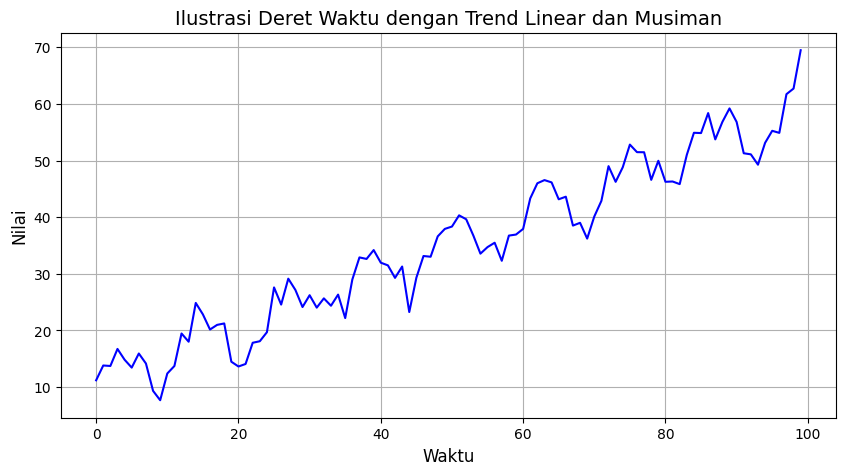

In [553]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [554]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [555]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [556]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     416.5
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           2.33e-71
Time:                        14:56:49   Log-Likelihood:                -207.26
No. Observations:                 100   AIC:                             440.5
Df Residuals:                      87   BIC:                             474.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       11.0048      0.768     14.327      0.0

**Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?**

**Jawab:**

Hasil estimasi menunjukkan bahwa koefisien periode sebesar 0.4945 berarti nilai deret meningkat rata-rata sebesar 0.4945 setiap periode. Koefisien untuk masing-masing bulan menunjukkan tingkat nilai deret pada awal periode, sedangkan perbedaan antar koefisien bulan menggambarkan pola musiman. Sebagai contoh, koefisien Januari sebesar 11.0048 menunjukkan nilai awal deret pada bulan Januari, sedangkan koefisien April sebesar 15.4274 menunjukkan nilai awal yang lebih tinggi pada bulan April. Selanjutnya, nilai pada setiap bulan mengalami peningkatan mengikuti trend sebesar 0.4945 setiap periode. Hasil estimasi koefisien periode yang mendekati parameter awal sebesar 0.5 menunjukkan bahwa model mampu menangkap kecenderungan trend linear dengan baik.

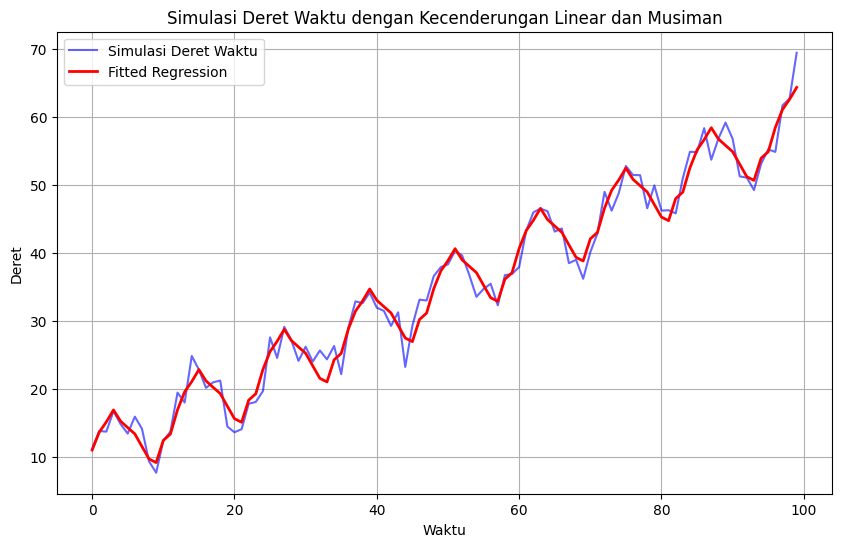

In [557]:

# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

**Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!**

In [558]:
# uji asumsi model

# ==========================================
# UJI ASUMSI MODEL TREND LINEAR + MUSIMAN
# ==========================================

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy.stats import shapiro

# Residual model
residual = model_mix.resid

# 1. Uji Breusch-Pagan
# H0: residual bersifat homoskedastis
exog_bp = sm.add_constant(model_mix.fittedvalues)
bp_test = het_breuschpagan(residual, exog_bp)

print("=== Uji Breusch-Pagan ===")
print("LM Statistic :", bp_test[0])
print("LM p-value   :", bp_test[1])
print("F Statistic  :", bp_test[2])
print("F p-value    :", bp_test[3])


# 2. Uji Ljung-Box
# H0: tidak terdapat autokorelasi residual
ljung = acorr_ljungbox(residual, lags=20, return_df=True)

print("\n=== Uji Ljung-Box ===")
print(ljung)


# 3. Uji Shapiro-Wilk
# H0: residual berdistribusi normal
shapiro_test = shapiro(residual)

print("\n=== Uji Shapiro-Wilk ===")
print("Statistic :", shapiro_test.statistic)
print("p-value   :", shapiro_test.pvalue)

=== Uji Breusch-Pagan ===
LM Statistic : 1.4133906548451702
LM p-value   : 0.2344943397887586
F Statistic  : 1.4049807077743213
F p-value    : 0.23875769396767818

=== Uji Ljung-Box ===
      lb_stat  lb_pvalue
1    0.052179   0.819315
2    0.099173   0.951623
3    0.917235   0.821267
4    1.040683   0.903566
5    1.078009   0.956032
6    1.502245   0.959345
7    1.870591   0.966654
8    6.037504   0.643031
9    7.587959   0.576142
10   8.932129   0.538557
11   8.959924   0.625592
12  17.952247   0.117148
13  18.767905   0.130477
14  18.803363   0.172600
15  19.752442   0.181636
16  20.911282   0.181946
17  23.695806   0.127939
18  27.806989   0.065054
19  27.834537   0.086665
20  28.916542   0.089416

=== Uji Shapiro-Wilk ===
Statistic : 0.9941893475767232
p-value   : 0.9483824337086459


Berdasarkan hasil pengecekan asumsi, model regresi dengan kecenderungan linear dan musiman tidak menunjukkan adanya pelanggaran asumsi regresi. Uji Breusch-Pagan menghasilkan p-value sebesar 0.2345 yang menunjukkan tidak terdapat heteroskedastisitas. Uji Ljung-Box pada lag 1 hingga 20 menghasilkan p-value lebih besar dari 0.05 sehingga tidak terdapat bukti adanya autokorelasi residual.

Uji Shapiro-Wilk menghasilkan p-value sebesar 0.9484 sehingga residual dapat dianggap berdistribusi normal. Dengan demikian, asumsi homoskedastisitas, independensi residual, dan normalitas telah terpenuhi, sehingga model dapat dikatakan sudah memadai.Berdasarkan hasil pengecekan asumsi, model regresi dengan kecenderungan linear dan musiman tidak menunjukkan adanya pelanggaran asumsi regresi.

Uji Breusch-Pagan menghasilkan p-value sebesar 0.2345 yang menunjukkan tidak terdapat heteroskedastisitas. Uji Ljung-Box pada lag 1 hingga 20 menghasilkan p-value lebih besar dari 0.05 sehingga tidak terdapat bukti adanya autokorelasi residual. Selanjutnya, uji Shapiro-Wilk menghasilkan p-value sebesar 0.9484 sehingga residual dapat dianggap berdistribusi normal. Dengan demikian, asumsi homoskedastisitas, independensi residual, dan normalitas telah terpenuhi, sehingga model dapat dikatakan sudah memadai.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [559]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

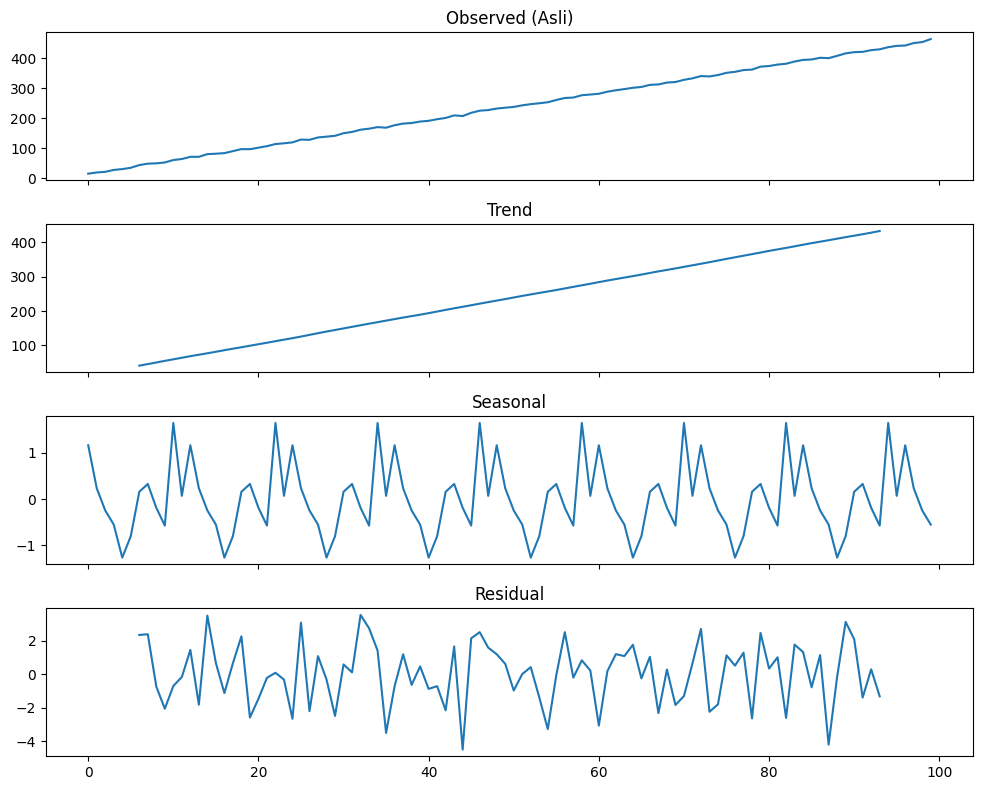

In [560]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

**Jawab:**

Hasil dekomposisi ini menunjukkan bahwa data simulasi didominasi oleh tren linier positif yang sangat kuat, di mana nilainya terus naik secara stabil dari sekitar 0 hingga melebihi 400. Komponen Trend memvisualisasikan arah garis lurus ini secara bersih (bagian ujungnya terpotong karena perhitungan moving average periode 12), sementara Observed menampilkan bentuk data aslinya yang mengikuti alur tren tersebut.

Komponen musiman (Seasonal) dan acak (Residual) pengaruhnya tergolong sangat kecil. Pola musiman memang berulang tiap 12 periode, tetapi rentang nilainya cuma berkisar di antara -1.5 sampai 1.5. Angka ini terhitung sedikit kalau dibandingkan dengan nilai trennya yang mencapai ratusan. Begitu juga dengan residualnya yang hanya berfluktuasi acak di sekitar angka 0 (antara -4 sampai 3), membuktikan kalau variasi acak di data ini sangat minim dan model aditif berhasil memisahkan komponennya dengan rapi.

In [561]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

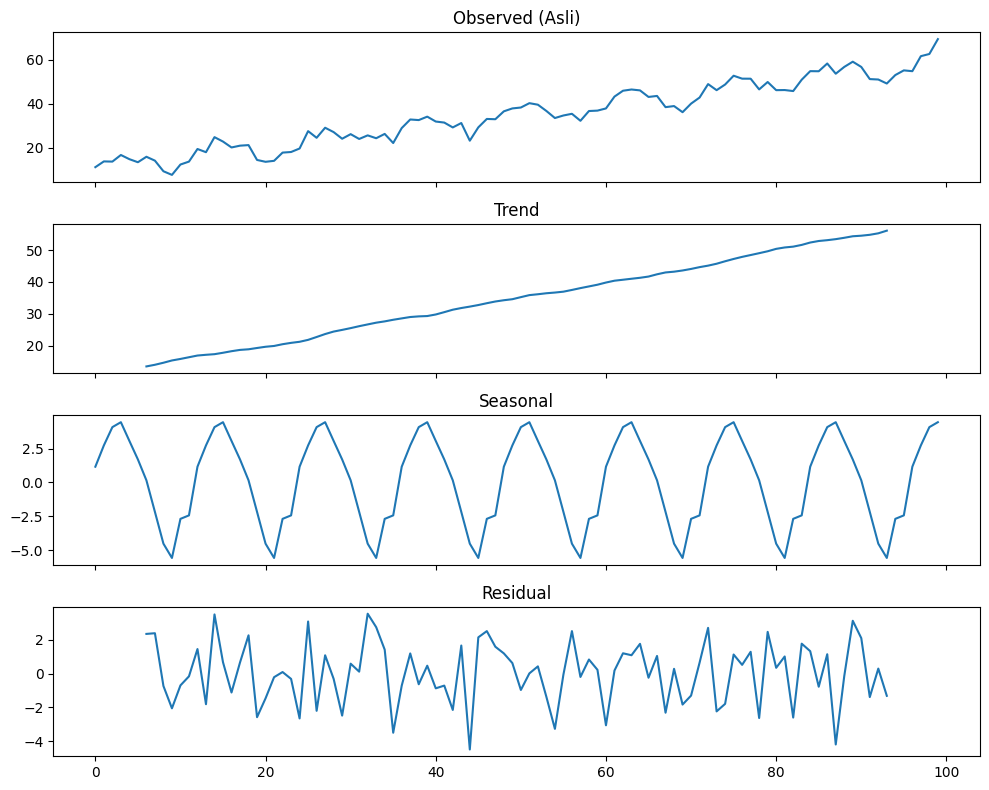

In [562]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

**Jawab:**

Hasil dekomposisi menunjukkan bahwa data memiliki tren naik yang jelas (upward trend) serta dengan pola musiman yang sangat teratur. Pada grafik Observed, terlihat fluktuasi yang terus bergerak naik dari kisaran nilai 10 hingga mendekati 70. Grafik Trend memisahkan arah jangka panjang tersebut dan memperlihatkan garis kenaikan yang konsisten serta mulus secara linier.

Pola berulang bisa terlihat pada grafik Seasonal, di mana terdapat gelombang naik-turun yang konsisten di setiap siklusnya (sekitar -5 hingga +4).

Grafik Residual memperlihatkan noise atau sisa fluktuasi acak yang tersebar di sekitar angka 0 (antara -4 hingga 3). Karena sisaannya terdistribusi cukup acak tanpa membentuk pola baru, ini menandakan bahwa komponen tren dan musiman sudah berhasil dipisahkan dengan sangat baik oleh model.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [563]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(EMPAT_DIGIT_TERAKHIR_NIM)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05, 10 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

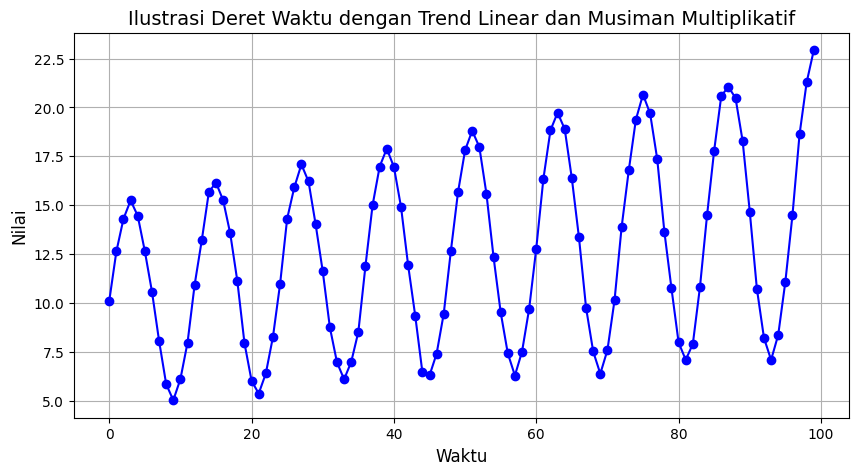

In [564]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [565]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

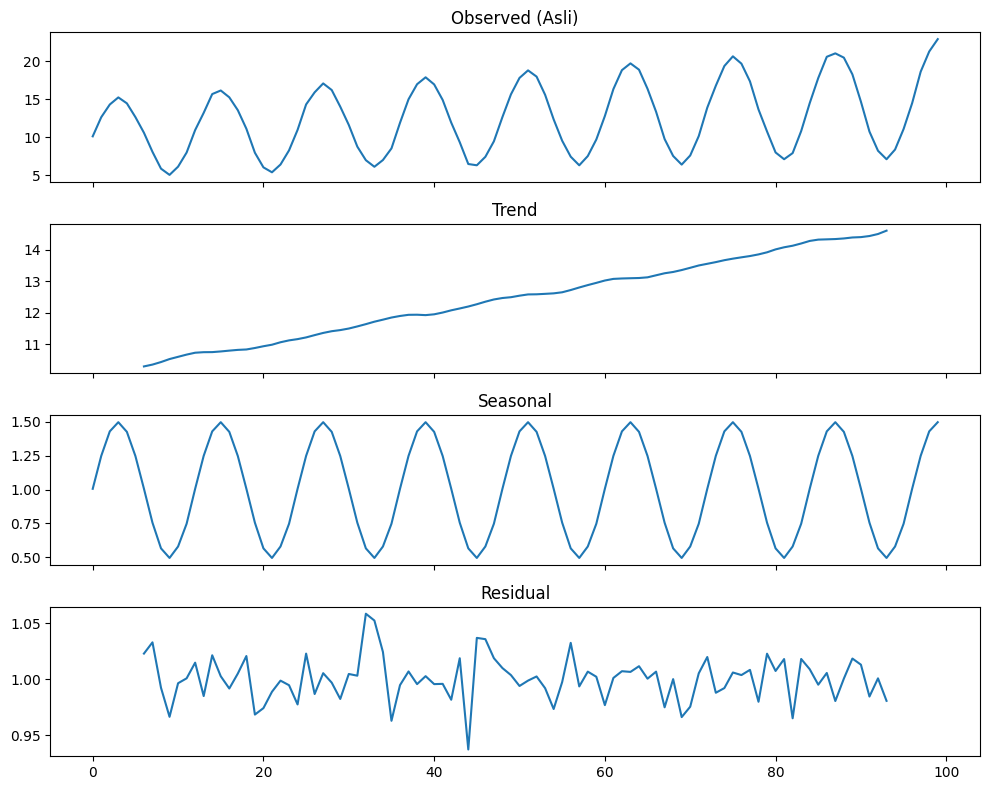

In [566]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

**Jawab:**

Grafik Observed menampilkan gelombang yang amplitudonya semakin lama semakin membesar seiring bertambahnya waktu (dari rentang 5 hingga 15 naik ke 7 hingga 22). Komponen Trend memisahkan tren positif yang merayap naik dari nilai 10 hingga 14.5, sedangkan Seasonal berhasil menangkap faktor pengali musiman berbentuk gelombang sinus yang sangat rapi berkisar antara 0.5 hingga 1.5. Terakhir, grafik Residual berfluktuasi secara acak di sekitar nilai pengali 1 (range 0.94 hingga 1.06), menegaskan bahwa model multiplikatif ini sangat pas dan tidak meninggalkan pola yang tertinggal.

In [567]:
# Parameter
np.random.seed(EMPAT_DIGIT_TERAKHIR_NIM)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

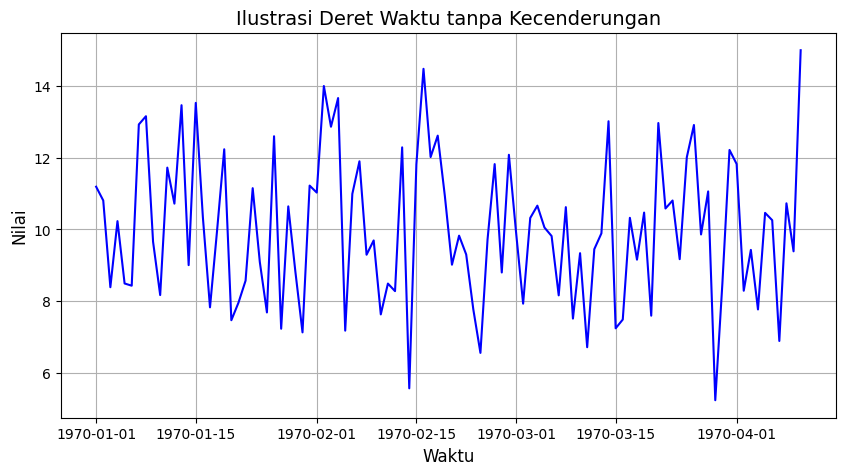

In [568]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

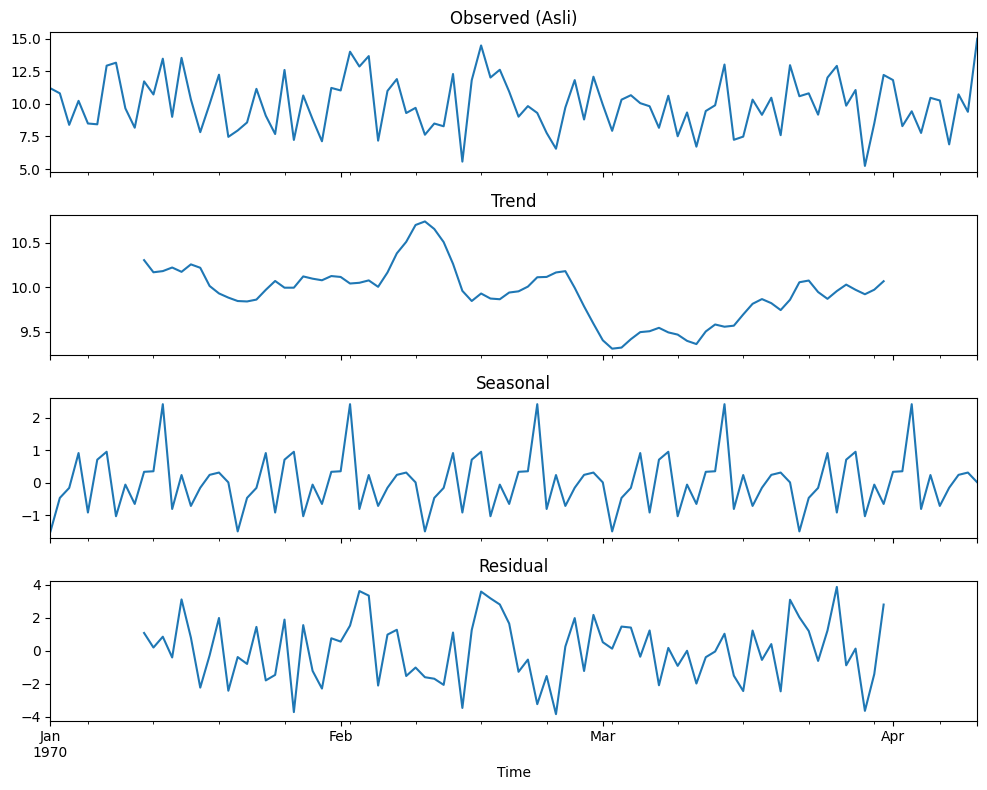

In [569]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

**Jawab:**

Hasil dekomposisi aditif pada data periode Januari hingga April 1970 ini menunjukkan bahwa data Observed terus berfluktuasi naik-turun di kisaran angka 5 sampai 15 tanpa adanya tren jangka panjang yang dominan. Hal ini terlihat jelas dari panel Trend yang cenderung datar dan bergerak stabil di kisaran 9,3 hingga 10,7, mengindikasikan bahwa data bersifat relatif stasioner.

Ppanel Seasonal memperlihatkan adanya pola musiman yang sangat teratur dengan puncak lonjakan tajam berkala pada rentang -1,5 hingga +2,5.

TKomponen Residual berfluktuasi secara acak di sekitar angka 0 (antara -4 hingga +4), yang menandakan bahwa tidak ada pola tersembunyi yang tertinggal dan model aditif telah memisahkan tren serta musiman dengan sangat bersih.